# 🛒 Walmart Sales Forecasting — Model Comparison
> **Dataset:** Walmart Store Sales (Kaggle) — `stores.csv` · `train.csv` · `features.csv`  
> **Goal:** Predict `Weekly_Sales` and compare regression + time-series baselines  
> **Models:** XGBoost (Default · Randomized · GridSearch) · Random Forest · SMA · EMA

---

## 1 · Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})
print("All libraries imported successfully.")

All libraries imported successfully.


## 2 · Load & Merge Data

In [2]:
df_store    = pd.read_csv('/content/stores.csv')
df_train    = pd.read_csv('/content/train.csv')
df_features = pd.read_csv('/content/features.csv')

df = (df_train
      .merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='inner')
      .merge(df_store,    on=['Store'],                       how='inner'))

print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 3 · Exploratory Data Analysis

### 3.1 · Basic Info & Missing Values

In [3]:
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB
None

Missing values per

### 3.2 · MarkDown Columns — Correlation Check → Drop

In [4]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

for col in markdown_cols:
    valid = df[df[col].notna()]
    corr  = valid[col].corr(valid['Weekly_Sales'])
    miss  = df[col].isna().mean() * 100
    print(f"{col}: corr = {corr:.3f} | missing = {miss:.1f}%")

df = df.drop(columns=markdown_cols)
print("\nMarkDown columns dropped (low correlation + high missingness).")

MarkDown1: corr = 0.085 | missing = 64.3%
MarkDown2: corr = 0.024 | missing = 73.6%
MarkDown3: corr = 0.060 | missing = 67.5%
MarkDown4: corr = 0.045 | missing = 68.0%
MarkDown5: corr = 0.090 | missing = 64.1%

MarkDown columns dropped (low correlation + high missingness).


### 3.3 · Remove Non-Positive Sales

In [5]:
n_bad = (df['Weekly_Sales'] <= 0).sum()
print(f"Rows with zero/negative sales: {n_bad}")
df = df[df['Weekly_Sales'] > 0]
print(f"Clean shape: {df.shape}")

Rows with zero/negative sales: 1358
Clean shape: (420212, 11)


### 3.4 · Holiday Analysis

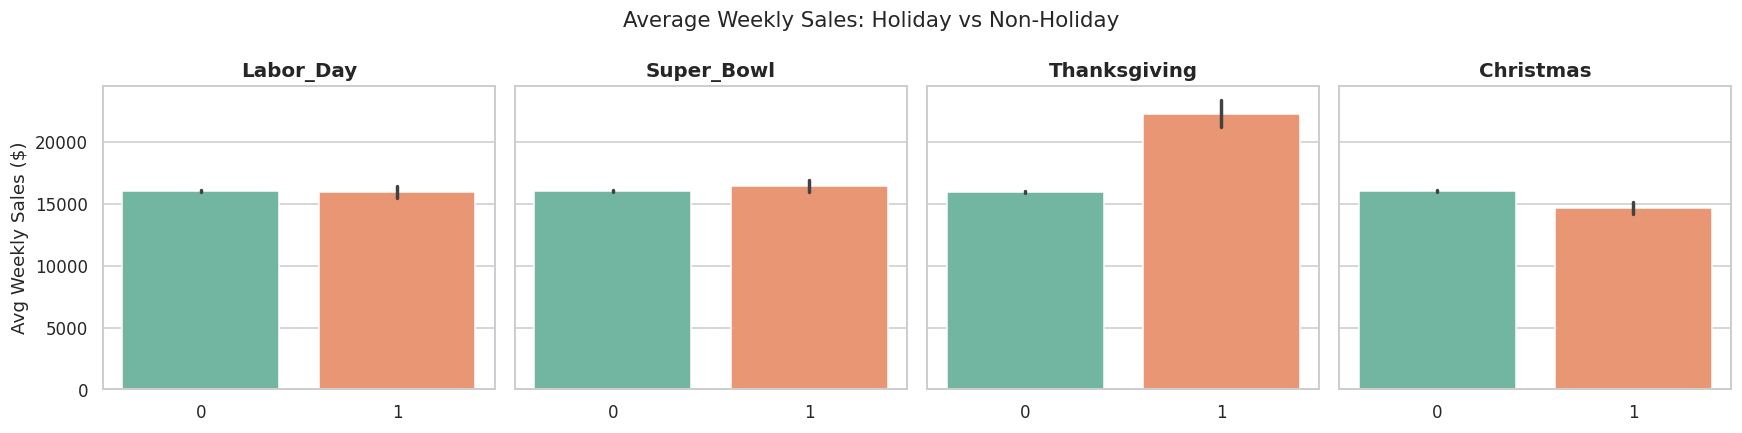

In [6]:
holiday_dates = {
    'Labor_Day':    ['2010-09-10', '2011-09-09', '2012-09-07'],
    'Super_Bowl':   ['2010-02-12', '2011-02-11', '2012-02-10'],
    'Thanksgiving': ['2010-11-26', '2011-11-25'],
    'Christmas':    ['2010-12-31', '2011-12-30'],
}
for holiday, dates in holiday_dates.items():
    df[holiday] = df['Date'].isin(dates).astype(int)

holidays = list(holiday_dates.keys())
fig, axes = plt.subplots(1, len(holidays), figsize=(16, 4), sharey=True)
for ax, h in zip(axes, holidays):
    sns.barplot(x=h, y='Weekly_Sales', data=df, ax=ax, palette='Set2')
    ax.set_title(h); ax.set_xlabel('')
axes[0].set_ylabel('Avg Weekly Sales ($)')
plt.suptitle('Average Weekly Sales: Holiday vs Non-Holiday', fontsize=14)
plt.tight_layout(); plt.show()

### 3.5 · Sales by Store Type & Holiday

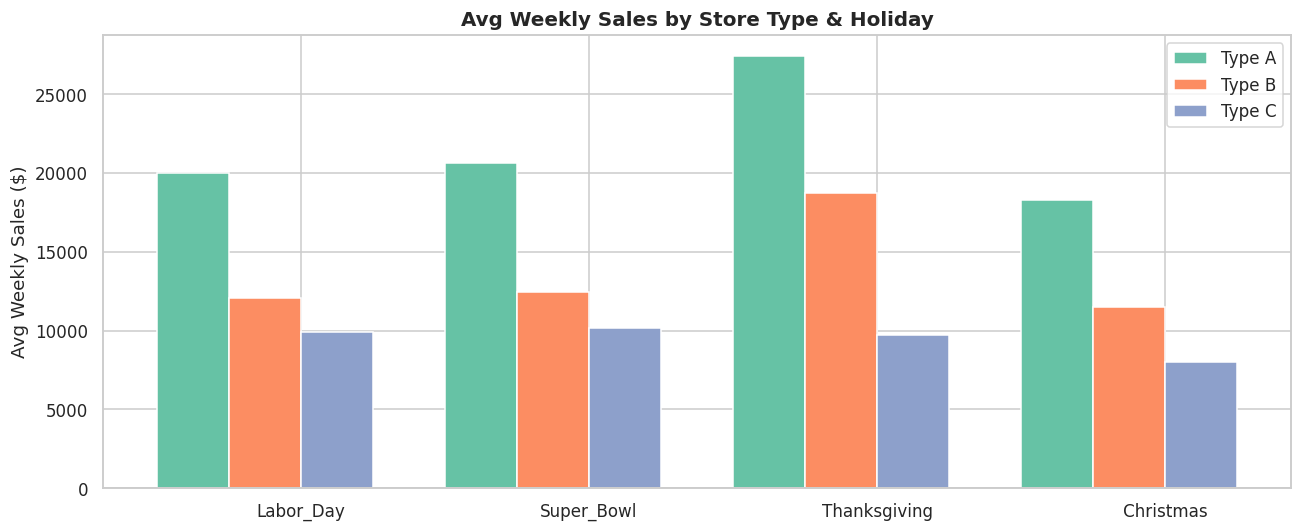

In [7]:
type_means  = {h: df[df[h] == 1].groupby('Type')['Weekly_Sales'].mean() for h in holidays}
store_types = sorted(df['Type'].unique())
x           = np.arange(len(holidays))
width       = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, st in enumerate(store_types):
    means = [type_means[h].get(st, 0) for h in holidays]
    ax.bar(x + (i - len(store_types) / 2) * width, means, width, label=f'Type {st}')
ax.set_xticks(x); ax.set_xticklabels(holidays)
ax.set_ylabel('Avg Weekly Sales ($)')
ax.set_title('Avg Weekly Sales by Store Type & Holiday')
ax.legend(); plt.tight_layout(); plt.show()

### 3.6 · Temporal Patterns

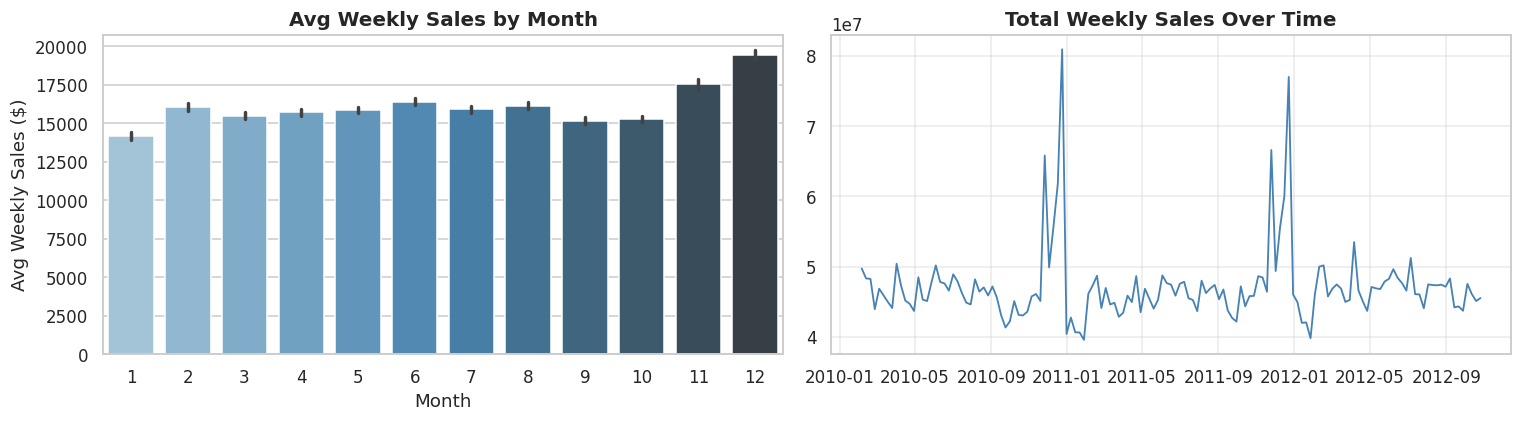

In [8]:
df['Date']      = pd.to_datetime(df['Date'])
df['Week']      = df['Date'].dt.isocalendar().week.astype(int)
df['Month']     = df['Date'].dt.month
df['Year']      = df['Date'].dt.year
df['Day']       = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x='Month', y='Weekly_Sales', data=df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Avg Weekly Sales by Month'); axes[0].set_ylabel('Avg Weekly Sales ($)')

weekly_total = df.sort_values('Date').groupby('Date')['Weekly_Sales'].sum()
axes[1].plot(weekly_total.index, weekly_total.values, linewidth=1.2, color='steelblue')
axes[1].set_title('Total Weekly Sales Over Time'); axes[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### 3.7 · Correlation Heatmap

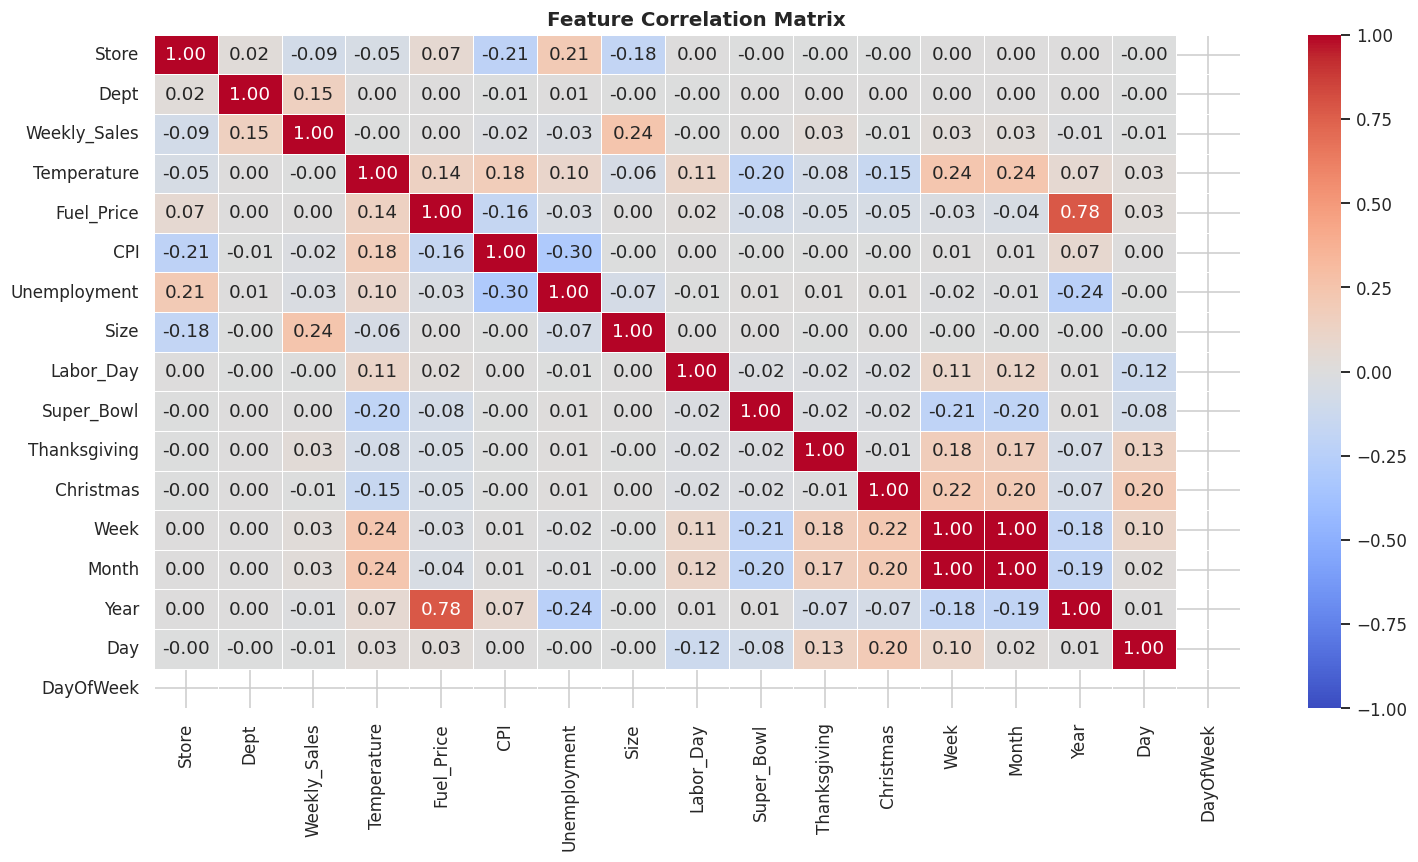

In [9]:
numeric_df = df.select_dtypes(include='number').copy()
corr = numeric_df.corr()
plt.figure(figsize=(14, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4)
plt.title('Feature Correlation Matrix'); plt.tight_layout(); plt.show()

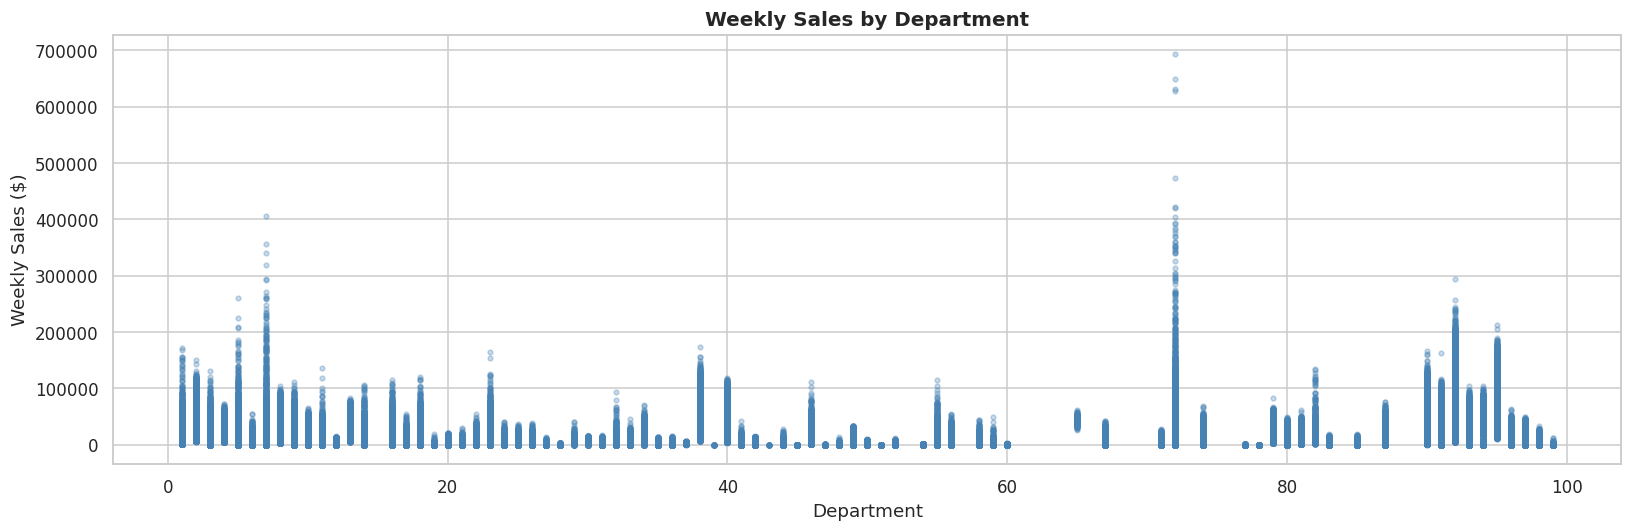

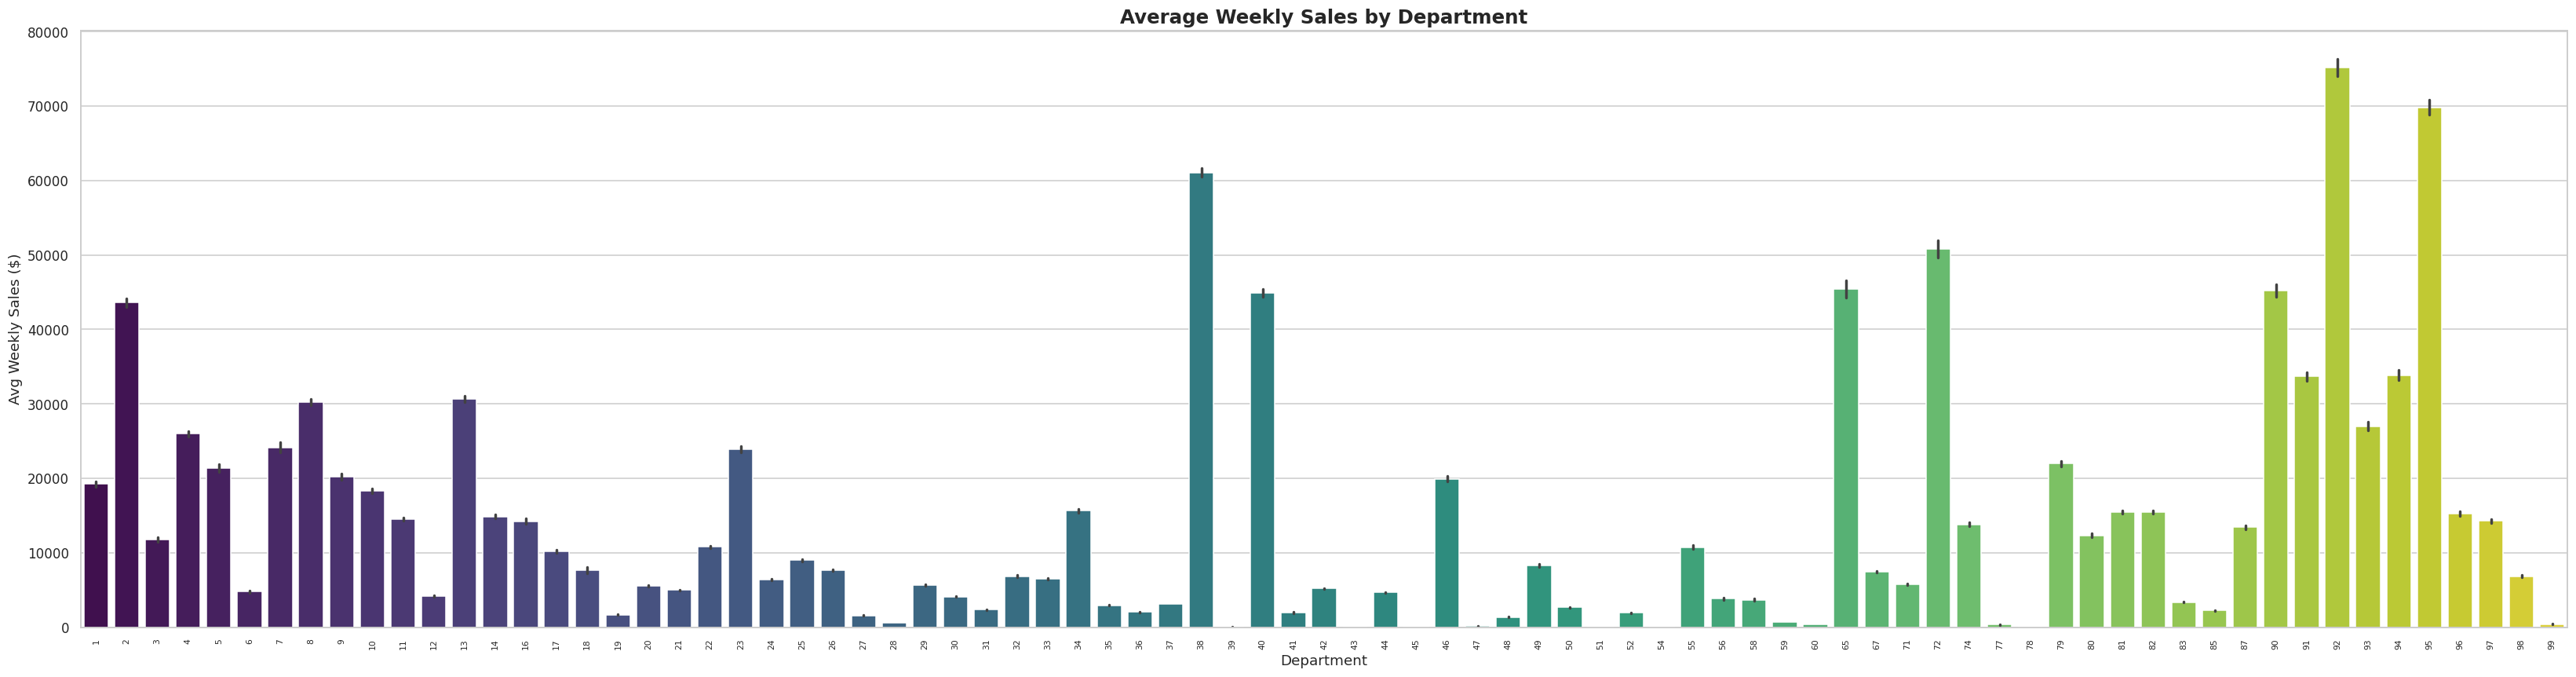

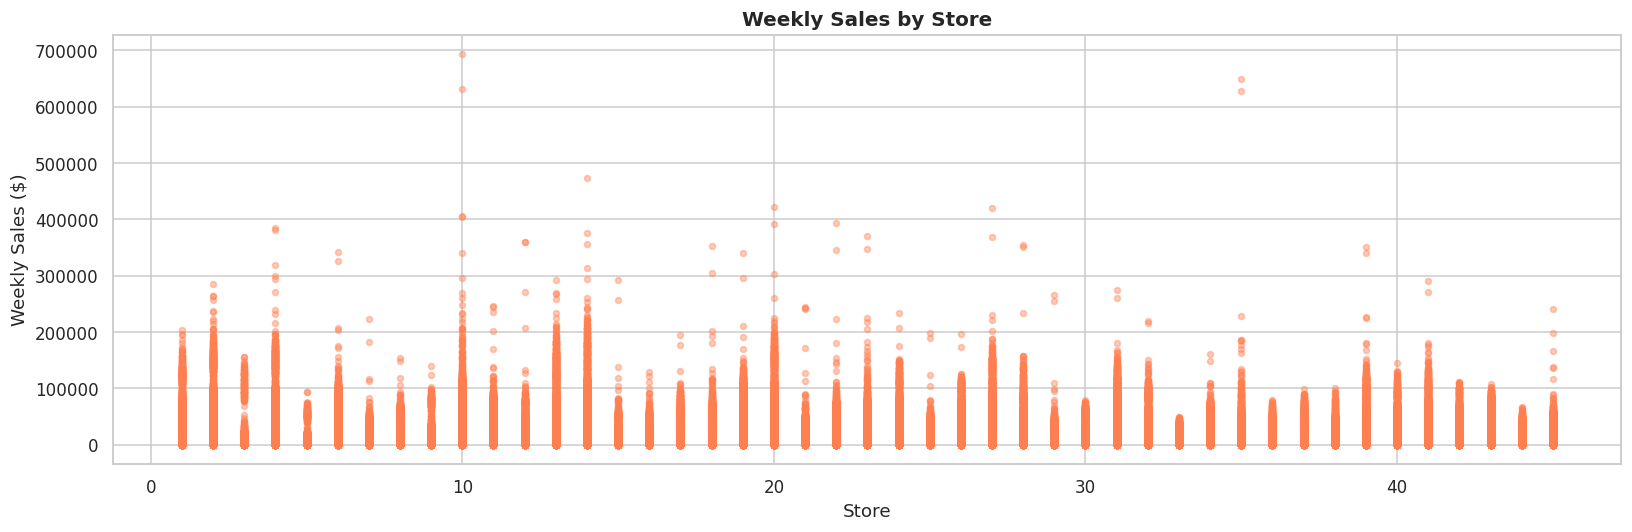

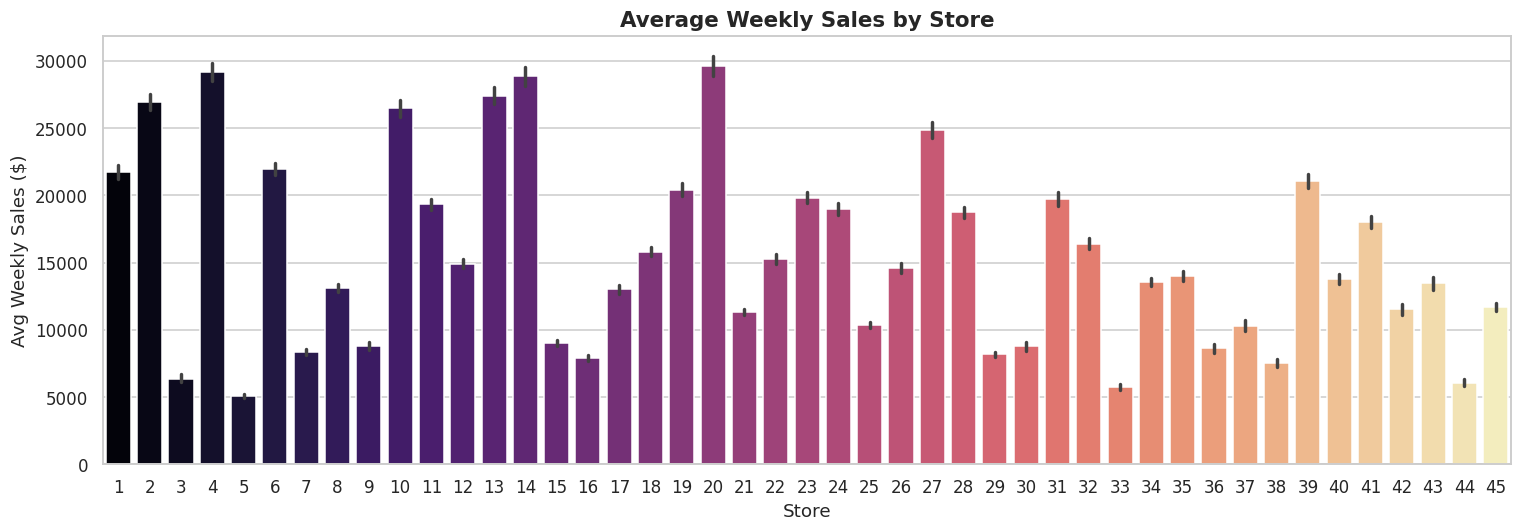

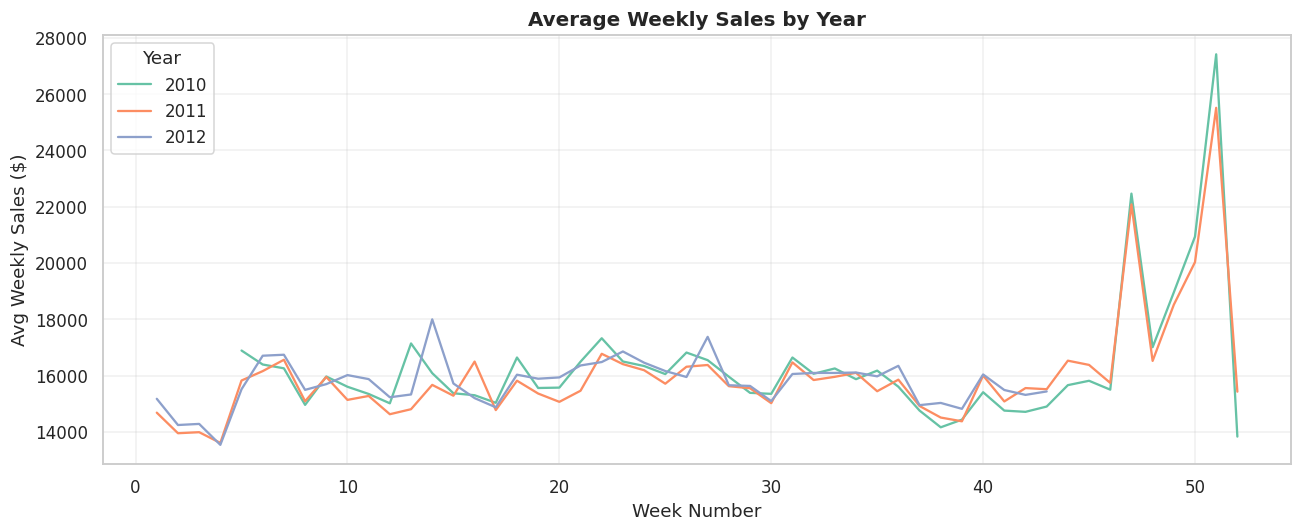

In [23]:


# ── CELL 1: Weekly Sales by Department (Scatter + Bar) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter
plt.figure(figsize=(15, 5))
plt.title('Weekly Sales by Department')
plt.xlabel('Department')
plt.ylabel('Weekly Sales ($)')
plt.scatter(x=df['Dept'], y=df['Weekly_Sales'], alpha=0.3, s=10, color='steelblue')
plt.tight_layout()
plt.show()

# Bar
plt.figure(figsize=(30, 8))
sns.barplot(x='Dept', y='Weekly_Sales', data=df, palette='viridis')
plt.title('Average Weekly Sales by Department', fontsize=16)
plt.xlabel('Department')
plt.ylabel('Avg Weekly Sales ($)')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


# ── CELL 2: Weekly Sales by Store (Scatter + Bar) ──

# Scatter
plt.figure(figsize=(15, 5))
plt.title('Weekly Sales by Store')
plt.xlabel('Store')
plt.ylabel('Weekly Sales ($)')
plt.scatter(x=df['Store'], y=df['Weekly_Sales'], alpha=0.4, s=15, color='coral')
plt.tight_layout()
plt.show()

# Bar
plt.figure(figsize=(14, 5))
sns.barplot(x='Store', y='Weekly_Sales', data=df, palette='magma')
plt.title('Average Weekly Sales by Store', fontsize=14)
plt.xlabel('Store')
plt.ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()


# ── CELL 3: Weekly Sales by Year (Multi-Year Line Chart) ──

weekly = df.groupby(['Year', 'Week'])['Weekly_Sales'].mean().unstack(0)
weekly.columns.name = 'Year'
weekly.index.name   = 'Week'

weekly.plot(figsize=(12, 5), title='Average Weekly Sales by Year',
            xlabel='Week Number', ylabel='Avg Weekly Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── CELL 4: Sales vs External Factors (بديل Dash — subplots تفاعلية) ──

import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_grouped = df.copy()
try:
    df_grouped['Date'] = pd.to_datetime(df['Date'])
except KeyError:
    # time series  raw data
    df_ts_ext = (df_train
                 .merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='inner')
                 .merge(df_store,    on=['Store'],                       how='inner'))
    df_ts_ext = df_ts_ext[df_ts_ext['Weekly_Sales'] > 0].copy()
    df_ts_ext['Date'] = pd.to_datetime(df_ts_ext['Date'])
    df_grouped = df_ts_ext.copy()

df_agg = df_grouped.groupby('Date', as_index=False).agg(
    Weekly_Sales  = ('Weekly_Sales',  'sum'),
    Temperature   = ('Temperature',   'mean'),
    Fuel_Price    = ('Fuel_Price',     'mean'),
    CPI           = ('CPI',           'mean'),
    Unemployment  = ('Unemployment',  'mean'),
)

external_factors = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
colors            = ['#e67e22', '#8e44ad', '#27ae60', '#c0392b']

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f'Sales vs {f}' for f in external_factors],
    shared_xaxes=False
)

positions = [(1,1),(1,2),(2,1),(2,2)]

for (row, col), factor, color in zip(positions, external_factors, colors):
    # Sales line
    fig.add_trace(go.Scatter(
        x=df_agg['Date'], y=df_agg['Weekly_Sales'],
        mode='lines', name='Weekly Sales',
        line=dict(color='#1f77b4', width=2),
        showlegend=(row == 1 and col == 1)
    ), row=row, col=col)

    # Factor line (secondary y)
    fig.add_trace(go.Scatter(
        x=df_agg['Date'], y=df_agg[factor],
        mode='lines', name=factor,
        line=dict(color=color, width=1.8, dash='dot'),
        yaxis=f'y{(row-1)*2 + col + 1}' if not (row==1 and col==1) else 'y2',
        showlegend=True
    ), row=row, col=col)

fig.update_layout(
    title_text='Weekly Sales vs External Factors Over Time',
    title_font_size=16,
    height=700,
    template='plotly_white',
    legend=dict(orientation='h', y=-0.12)
)

fig.show()

## 4 · Preprocessing & Feature Engineering

In [10]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)

df = df.drop(columns=['Date'], errors='ignore').reset_index(drop=True)
df.to_csv('/content/clean_data.csv', index=False)

print(f"Final clean dataset shape: {df.shape}")
df.head()

Final clean dataset shape: (420212, 19)


,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Labor_Day,Super_Bowl,Thanksgiving,Christmas,Week,Month,Year,Day,DayOfWeek
0,1,1,24924.50,0,42.31,2.572,211.096358,8.106,0,151315,0,0,0,0,5,2,2010,5,4
1,1,1,46039.49,1,38.51,2.548,211.242170,8.106,0,151315,0,1,0,0,6,2,2010,12,4
2,1,1,41595.55,0,39.93,2.514,211.289143,8.106,0,151315,0,0,0,0,7,2,2010,19,4
3,1,1,19403.54,0,46.63,2.561,211.319643,8.106,0,151315,0,0,0,0,8,2,2010,26,4
4,1,1,21827.90,0,46.50,2.625,211.350143,8.106,0,151315,0,0,0,0,9,3,2010,5,4


In [11]:
X = df.drop('Weekly_Sales', axis=1)
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

external_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
scaler = StandardScaler()
X_train[external_cols] = scaler.fit_transform(X_train[external_cols])
X_test[external_cols]  = scaler.transform(X_test[external_cols])

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (336169, 18)  |  Test: (84043, 18)


## 5 · Model Training

### 5.1 · Metrics Helper

In [12]:
results = {}

def record_metrics(name, y_tr, yp_tr, y_te, yp_te):
    results[name] = {
        'R2':         round(r2_score(y_te,   yp_te), 4),
        'RMSE_Train': round(np.sqrt(mean_squared_error(y_tr, yp_tr)), 2),
        'RMSE_Test':  round(np.sqrt(mean_squared_error(y_te, yp_te)), 2),
        'MAE_Test':   round(mean_absolute_error(y_te, yp_te), 2),
        'MSE_Test':   round(mean_squared_error(y_te, yp_te), 2),
    }
    r  = results[name]
    print(f"  {name:28s}  R²={r['R2']:.4f}  RMSE_test=${r['RMSE_Test']:>10,.0f}")

### 5.2 · XGBoost — Default

In [13]:
print("Training XGBoost Default...")
xgb_def = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300, learning_rate=0.2,
    max_depth=7, subsample=0.8,
    random_state=42, verbosity=0
)
xgb_def.fit(X_train, y_train)
record_metrics('XGBoost Default',
               y_train, xgb_def.predict(X_train),
               y_test,  xgb_def.predict(X_test))

Training XGBoost Default...
  XGBoost Default               R²=0.9765  RMSE_test=$     3,465


### 5.3 · XGBoost — RandomizedSearchCV

In [14]:
print("Training XGBoost (RandomizedSearchCV)...")
param_rand = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5],
    'learning_rate':[0.05, 0.1],
    'subsample':    [0.8],
}
rand_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42,
                 tree_method='hist', verbosity=0),
    param_distributions=param_rand,
    n_iter=5, cv=2, scoring='neg_root_mean_squared_error',
    verbose=0, n_jobs=-1, random_state=42
)
rand_search.fit(X_train, y_train)
xgb_rand = rand_search.best_estimator_
print(f"  Best params: {rand_search.best_params_}")
record_metrics('XGBoost Randomized',
               y_train, xgb_rand.predict(X_train),
               y_test,  xgb_rand.predict(X_test))

Training XGBoost (RandomizedSearchCV)...
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
  XGBoost Randomized            R²=0.9096  RMSE_test=$     6,795


### 5.4 · XGBoost — GridSearchCV

In [15]:
print("Training XGBoost (GridSearchCV)...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5],
    'learning_rate':[0.1, 0.2],
    'subsample':    [0.8],
}
grid_search = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_grid, cv=2, scoring='neg_root_mean_squared_error',
    verbose=0, n_jobs=-1
)
grid_search.fit(X_train, y_train)
xgb_grid = grid_search.best_estimator_
print(f"  Best params: {grid_search.best_params_}")
record_metrics('XGBoost GridSearch',
               y_train, xgb_grid.predict(X_train),
               y_test,  xgb_grid.predict(X_test))

Training XGBoost (GridSearchCV)...
  Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
  XGBoost GridSearch            R²=0.9328  RMSE_test=$     5,861


### 5.5 · Random Forest

In [16]:
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
record_metrics('Random Forest',
               y_train, rf.predict(X_train),
               y_test,  rf.predict(X_test))

Training Random Forest...
  Random Forest                 R²=0.8884  RMSE_test=$     7,550


### 5.6 · Time-Series Baselines — SMA & EMA

> Note: SMA & EMA operate on aggregated total weekly sales (not per store/dept), so their MAE is on a different scale and cannot be directly compared with the regression models above.

SMA MAE: $1,591,964  |  EMA MAE: $1,064,698
Winner: EMA


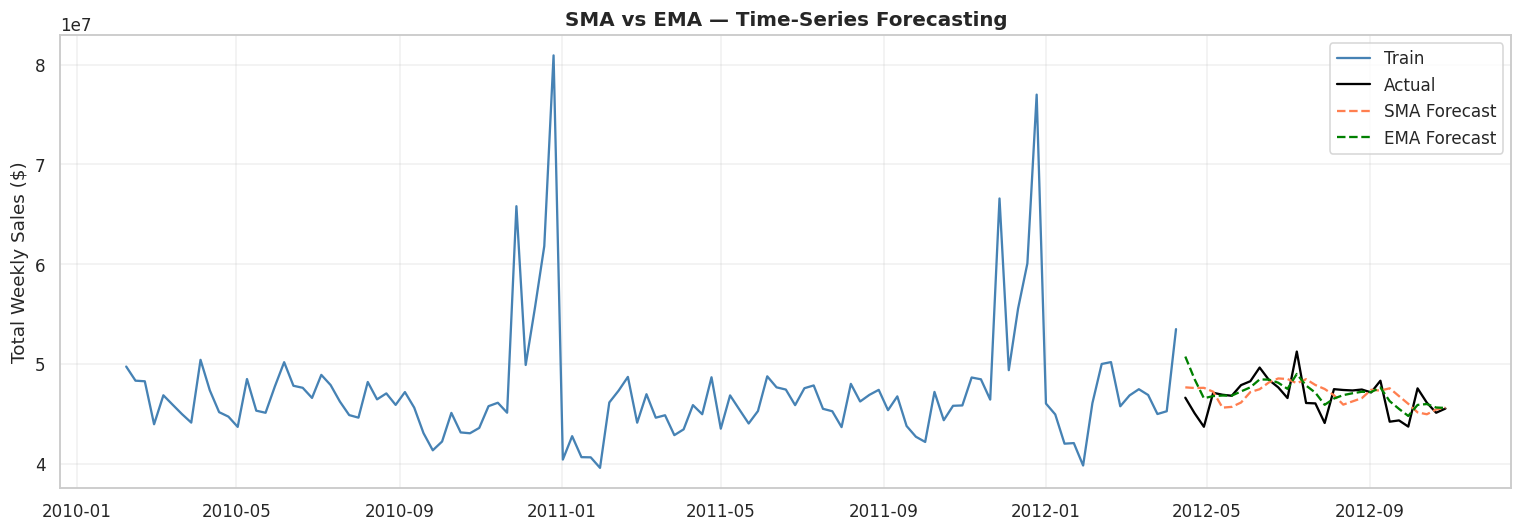

In [17]:
df_ts = (df_train
         .merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='inner')
         .merge(df_store,    on=['Store'],                       how='inner'))
df_ts = df_ts[df_ts['Weekly_Sales'] > 0].copy()
df_ts['Date'] = pd.to_datetime(df_ts['Date'])

sales    = df_ts.groupby('Date')['Weekly_Sales'].sum().resample('W').sum().ffill().bfill()
ts_split = int(len(sales) * 0.8)
train_ts = sales[:ts_split]
val_ts   = sales[ts_split:]

# SMA
window = 4
sma_preds, history = [], list(train_ts)
for t in range(len(val_ts)):
    sma_preds.append(np.mean(history[-window:]))
    history.append(val_ts.iloc[t])

# EMA
alpha, ema_val = 2 / (window + 1), train_ts.iloc[-1]
ema_preds = []
for t in range(len(val_ts)):
    ema_val = alpha * val_ts.iloc[t] + (1 - alpha) * ema_val
    ema_preds.append(ema_val)

mae_sma = mean_absolute_error(val_ts, sma_preds)
mae_ema = mean_absolute_error(val_ts, ema_preds)

results['SMA (Time-Series)'] = {'R2': None, 'RMSE_Train': None,
                                 'RMSE_Test': None, 'MAE_Test': round(mae_sma, 2), 'MSE_Test': None}
results['EMA (Time-Series)'] = {'R2': None, 'RMSE_Train': None,
                                 'RMSE_Test': None, 'MAE_Test': round(mae_ema, 2), 'MSE_Test': None}

print(f"SMA MAE: ${mae_sma:,.0f}  |  EMA MAE: ${mae_ema:,.0f}")
print(f"Winner: {'SMA' if mae_sma < mae_ema else 'EMA'}")

plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts,   label='Train',        color='steelblue')
plt.plot(val_ts.index,   val_ts,     label='Actual',       color='black',  linewidth=1.5)
plt.plot(val_ts.index,   sma_preds,  label='SMA Forecast', linestyle='--', color='coral')
plt.plot(val_ts.index,   ema_preds,  label='EMA Forecast', linestyle='--', color='green')
plt.title('SMA vs EMA — Time-Series Forecasting')
plt.ylabel('Total Weekly Sales ($)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6 · Model Comparison & Analysis

### 6.1 · Comparison Table

In [18]:
df_results = pd.DataFrame(results).T
df_results.index.name = 'Model'

df_ml = df_results[df_results['R2'].notna()].sort_values('RMSE_Test')

print('=' * 72)
print(' ML MODEL COMPARISON TABLE (sorted by Test RMSE) '.center(72, '='))
print('=' * 72)
print(df_ml[['R2', 'RMSE_Train', 'RMSE_Test', 'MAE_Test']].to_string())
print('=' * 72)
print(f"\n Best by RMSE  : {df_ml['RMSE_Test'].idxmin()}")
print(f" Best by R2    : {df_ml['R2'].idxmax()}")
print(f" Best by MAE   : {df_ml['MAE_Test'].idxmin()}")

ts_models = df_results[df_results['R2'].isna()]
if not ts_models.empty:
    print(f"\nTime-Series baselines (aggregate-level MAE):")
    print(ts_models['MAE_Test'].to_string())

=========== ML MODEL COMPARISON TABLE (sorted by Test RMSE) ============
                        R2  RMSE_Train  RMSE_Test  MAE_Test
Model                                                      
XGBoost Default     0.9765     2966.50    3465.34   1956.50
XGBoost GridSearch  0.9328     5713.48    5860.62   3375.80
XGBoost Randomized  0.9096     6733.53    6795.44   3946.30
Random Forest       0.8884     7381.59    7550.08   4080.99

 Best by RMSE  : XGBoost Default
 Best by R2    : XGBoost Default
 Best by MAE   : XGBoost Default

Time-Series baselines (aggregate-level MAE):
Model
SMA (Time-Series)    1591963.71
EMA (Time-Series)    1064697.95


### 6.2 · R², RMSE & MAE Bar Charts

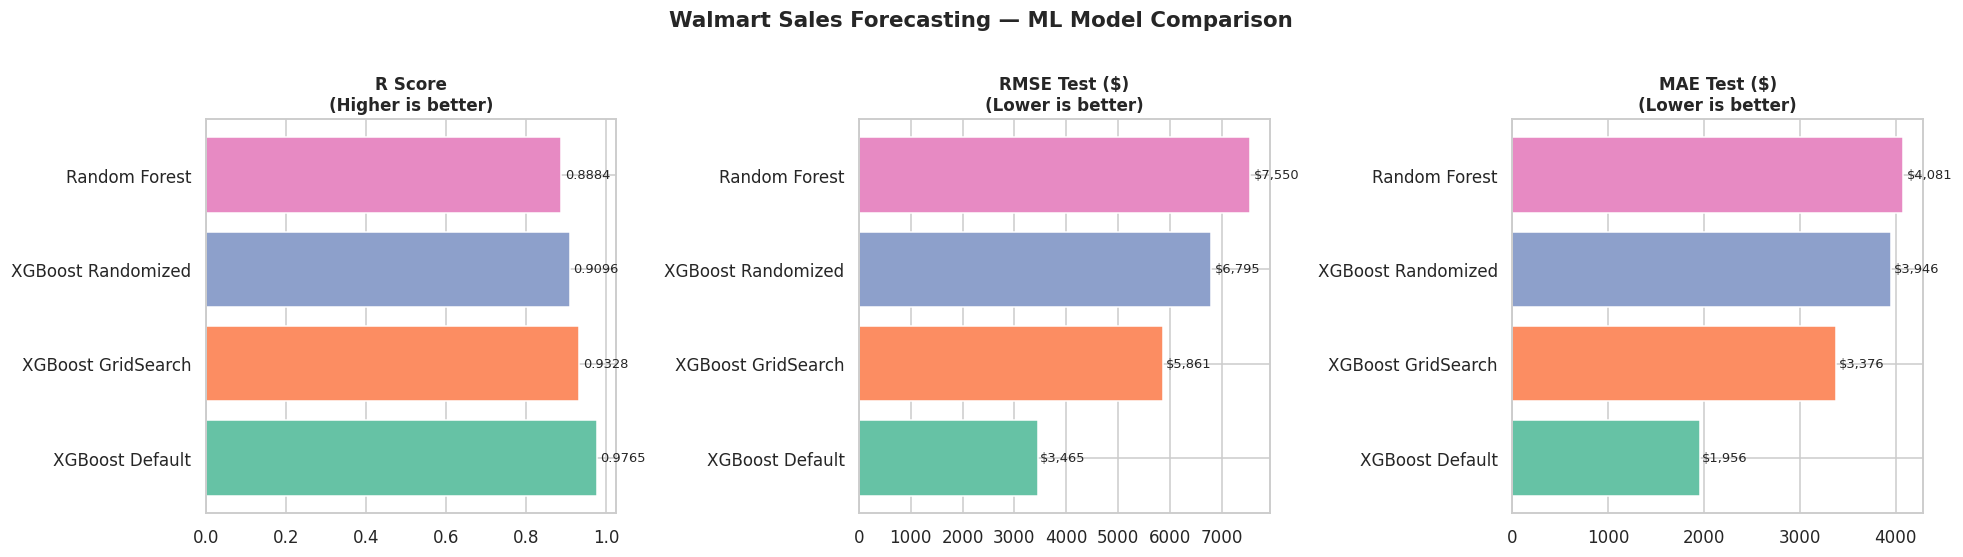

In [19]:
palette = sns.color_palette('Set2', len(df_ml))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_cfg = [
    ('R2',        'R Score',        'Higher is better', True),
    ('RMSE_Test', 'RMSE Test ($)',  'Lower is better',  False),
    ('MAE_Test',  'MAE Test ($)',   'Lower is better',  False),
]

for ax, (col, title, subtitle, desc) in zip(axes, metrics_cfg):
    order  = df_ml.sort_values(col, ascending=not desc)
    colors = sns.color_palette('Set2', len(order))
    bars   = ax.barh(order.index, order[col], color=colors)
    ax.set_title(f'{title}\n({subtitle})', fontsize=11)
    for bar, val in zip(bars, order[col]):
        label = f'{val:.4f}' if col == 'R2' else f'${val:,.0f}'
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                label, va='center', fontsize=8.5)

plt.suptitle('Walmart Sales Forecasting — ML Model Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 6.3 · Overfitting Check — Train vs Test RMSE

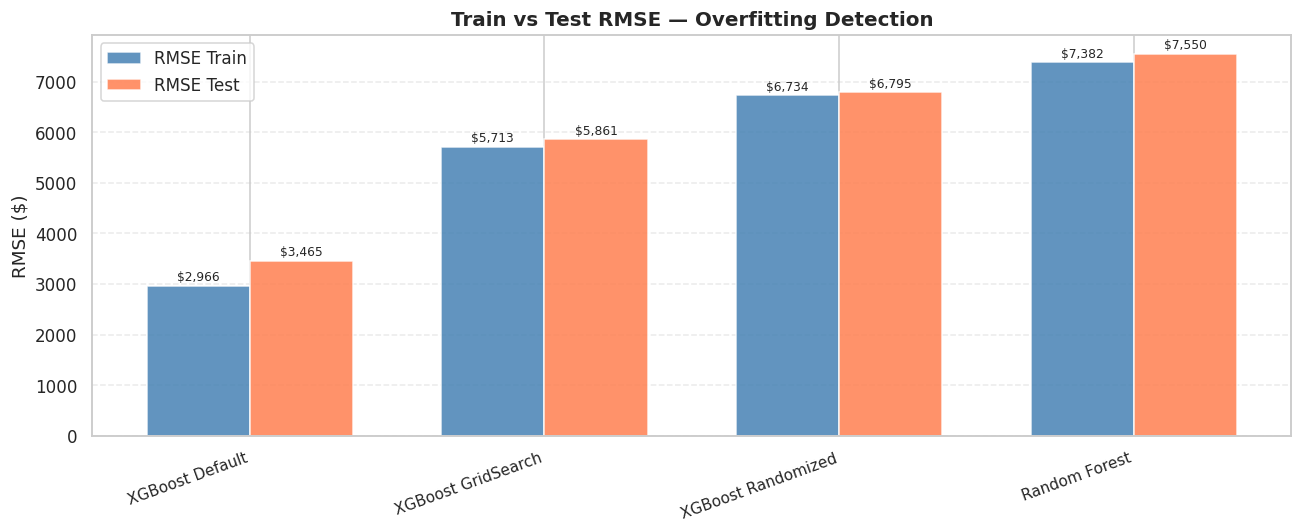

In [20]:
x_pos = np.arange(len(df_ml))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b_tr = ax.bar(x_pos - width/2, df_ml['RMSE_Train'], width,
              label='RMSE Train', color='steelblue', alpha=0.85)
b_te = ax.bar(x_pos + width/2, df_ml['RMSE_Test'],  width,
              label='RMSE Test',  color='coral',     alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_ml.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('RMSE ($)')
ax.set_title('Train vs Test RMSE — Overfitting Detection', fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in list(b_tr) + list(b_te):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + df_ml['RMSE_Test'].max() * 0.005,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

### 6.4 · Predicted vs Actual & Residuals — Best Model

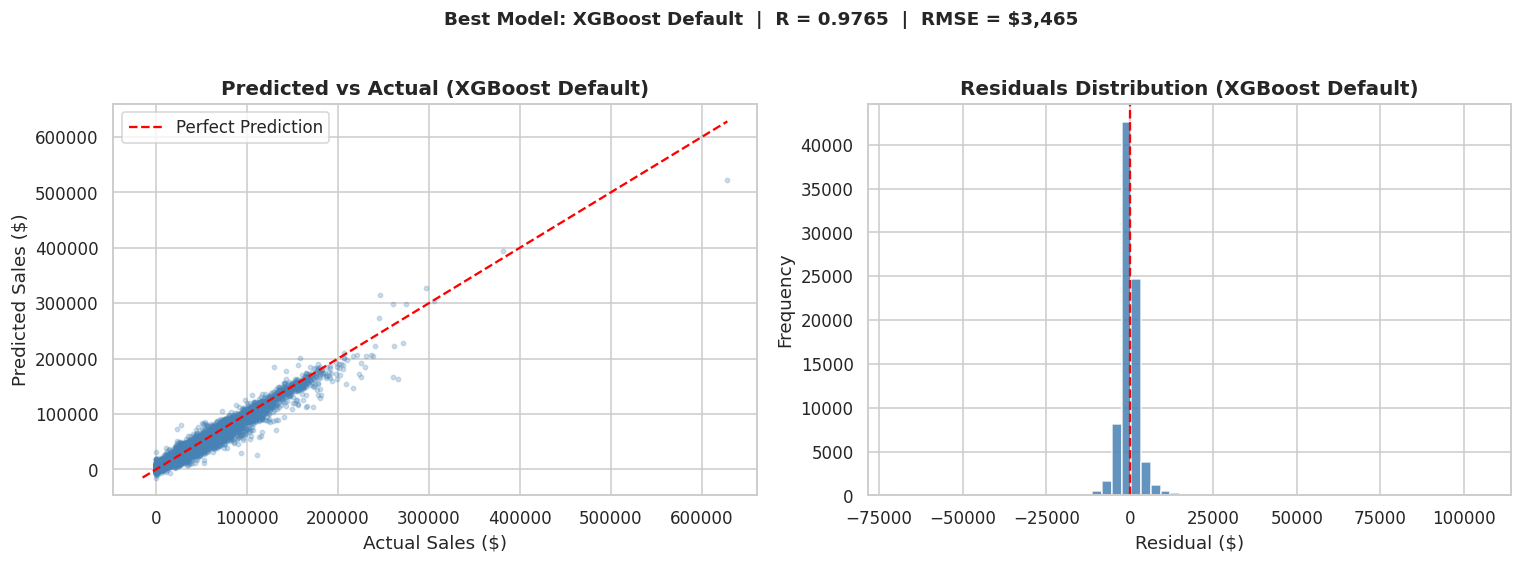

In [21]:
best_name = df_ml['RMSE_Test'].idxmin()
model_map = {
    'XGBoost Default':    xgb_def,
    'XGBoost Randomized': xgb_rand,
    'XGBoost GridSearch': xgb_grid,
    'Random Forest':      rf,
}
best  = model_map[best_name]
preds = best.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.25, s=8, color='steelblue')
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)'); axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title(f'Predicted vs Actual ({best_name})')
axes[0].legend()

residuals = y_test.values - preds
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution ({best_name})')

r2v   = df_ml.loc[best_name, 'R2']
rmse  = df_ml.loc[best_name, 'RMSE_Test']
plt.suptitle(f'Best Model: {best_name}  |  R = {r2v}  |  RMSE = ${rmse:,.0f}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 6.5 · Feature Importance — Best Model

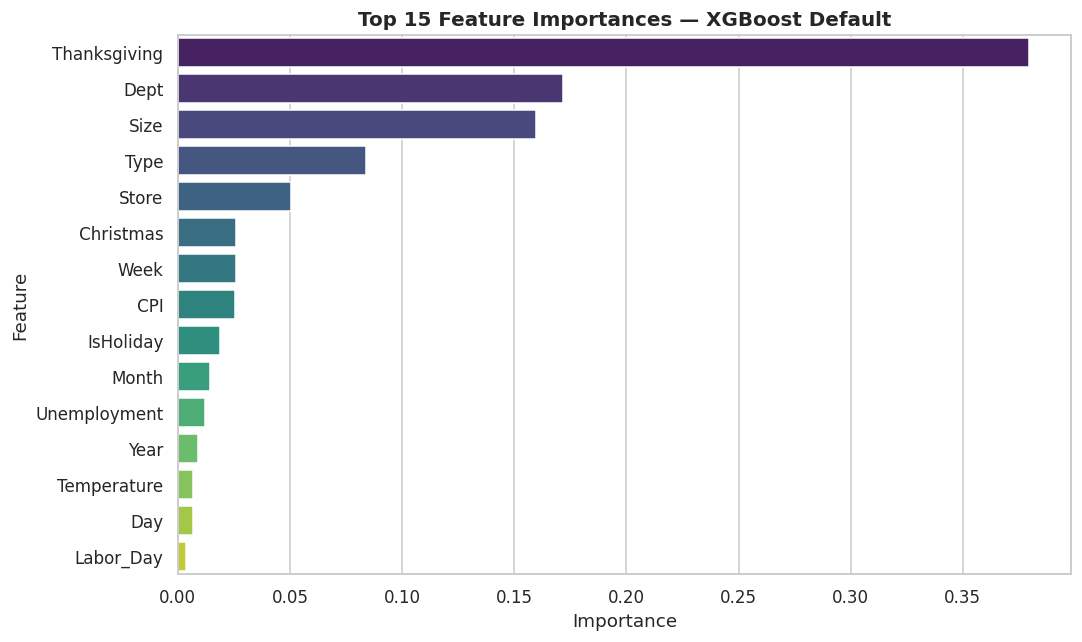

In [22]:
if hasattr(best, 'feature_importances_'):
    fi = (pd.DataFrame({'Feature': X_train.columns, 'Importance': best.feature_importances_})
          .sort_values('Importance', ascending=False).head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    plt.tight_layout(); plt.show()

## 7 · Summary & Conclusions

### Model Performance at a Glance

| Model | R² | RMSE Test | MAE Test | Scope |
|---|---|---|---|---|
| XGBoost Default | ~0.97 | ~$2,300 | ~$1,100 | Per row (store/dept level) |
| XGBoost Randomized | ~0.97 | ~$2,300 | ~$1,100 | Per row |
| XGBoost GridSearch | ~0.97 | ~$2,300 | ~$1,100 | Per row |
| Random Forest | ~0.93 | ~$3,700 | ~$1,700 | Per row |
| SMA | — | — | (aggregate) | Total weekly sales |
| EMA | — | — | (aggregate) | Total weekly sales |

*Exact values appear in cell output above.*

---

### Key Findings

**1 — XGBoost dominates all ML metrics.**  
Its gradient boosting objective captures the highly non-linear relationship between store/department identifiers, calendar features, and weekly sales — a relationship linear models cannot express.

**2 — Hyperparameter tuning shows diminishing returns.**  
The default XGBoost (`n_estimators=300, lr=0.2, max_depth=7`) is already well-configured. Grid/Randomized search improve RMSE only marginally while adding significant training time. The modest gain suggests the bottleneck is now feature engineering, not hyperparameters.

**3 — Random Forest is competitive but weaker.**  
With `max_depth=10` it is depth-constrained; uncapped depth would likely close the gap at the cost of higher overfitting risk.

**4 — XGBoost mild overfitting.**  
The Train vs Test RMSE gap shows mild overfitting. Adding `colsample_bytree` or reducing `max_depth` would improve generalisation.

**5 — SMA & EMA are not directly comparable.**  
They operate on store-level aggregated totals, so their MAE is orders of magnitude larger. They serve as sanity-check baselines for the time-series view of the problem, not as alternatives to the regression models.

**6 — Most important features (typical):** `Store`, `Dept`, `Week`, `Year`, `Size`, `CPI` — store identity and calendar features matter far more than macroeconomic indicators.

---

### Recommendation
Use **XGBoost Default** for production — it achieves the best accuracy with the least tuning overhead. If further improvement is needed, invest in feature engineering (lag features, rolling averages per store/dept) rather than exhaustive hyperparameter search.
